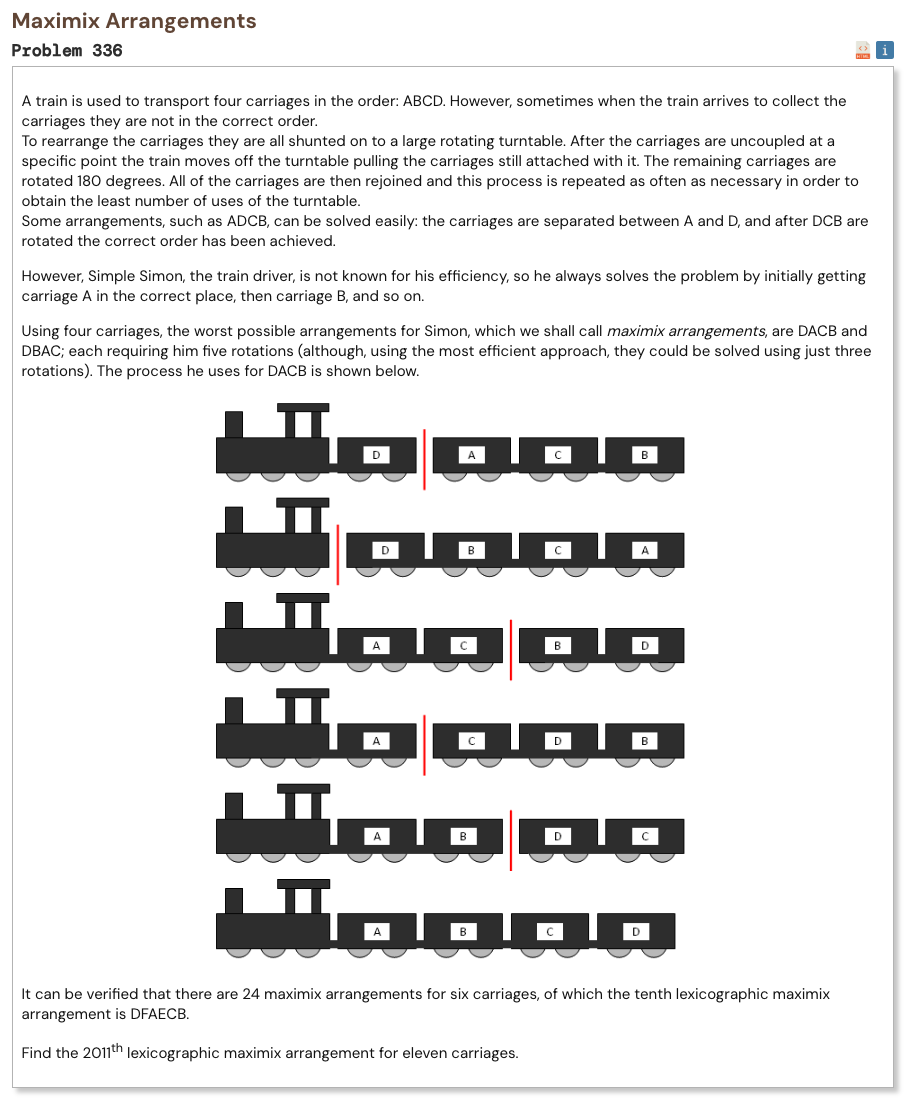

## Initial approach

* model each turntable use as reversing a suffix of the train
* Simon fixes A, then B, then C, and so on
* the worst case happens when each target carriage is neither already correct nor at the easy last position
* instead of checking every permutation, build only the worst-case arrangements backwards
* start from the sorted train and undo Simon’s worst-case moves
* this generates exactly the maximix arrangements
* sort them lexicographically and take the requested one

In [1]:
def reverse_suffix(arr, index):
    return arr[:index] + arr[index:][::-1]

def generate_maximix(n):
    sorted_train = list(range(n))
    states = [reverse_suffix(sorted_train, n - 2)]

    for i in range(n - 3, -1, -1):
        new_states = []

        for state in states:
            temp = reverse_suffix(state, i)

            for j in range(i + 1, n - 1):
                new_states.append(reverse_suffix(temp, j))

        states = new_states

    return states

def arrangement_to_string(arr):
    return "".join(chr(ord("A") + x) for x in arr)

def solve():
    arrangements = generate_maximix(11)
    arrangements = sorted(arrangement_to_string(arr) for arr in arrangements)
    return arrangements[2010]

check = sorted(arrangement_to_string(arr) for arr in generate_maximix(6))
assert len(check) == 24
assert check[9] == "DFAECB"

In [2]:
%%time
result = solve()
print("Result:", result)

Result: CAGBIHEFJDK
CPU times: user 506 ms, sys: 20.1 ms, total: 526 ms
Wall time: 529 ms
